# Optimizing Loan Approval Decisions Using Cost-Sensitive Machine Learning

## Objective
Build a machine learning model to predict loan default risk and support approval decisions under asymmetric business costs.

## Business Problem
A lending platform must balance credit losses with loan growth. Approving risky borrowers can increase defaults and losses, while rejecting too many borrowers can reduce revenue and customer growth. This project evaluates baseline models for predicting default risk using Lending Club loan data.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/accepted_2014_to_2018Q4_CLEANED.csv", low_memory=False)
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,disbursement_method,target
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0
3,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0
4,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,0


In [12]:
df.columns.tolist()

['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'purpose',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 

In [11]:
cols_to_drop = [
    'loan_status',
    'issue_d',
    'earliest_cr_line',
    'sec_app_earliest_cr_line',
    'pymnt_plan',
    'zip_code'
]

In [8]:
df = df.drop(columns=cols_to_drop)

In [9]:
print("Final shape:", df.shape)
print("\nTarget distribution:")
print(df['target'].value_counts(normalize=True))

print("\nAny missing target?", df['target'].isna().sum())

Final shape: (1117353, 102)

Target distribution:
target
0    0.791274
1    0.208726
Name: proportion, dtype: float64

Any missing target? 0


In [13]:
df_model = df.copy()
print(df_model.shape)

(1117353, 102)


In [14]:
X = df_model.drop(columns=['target'])
y = df_model['target']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1117353, 101)
y shape: (1117353,)


In [15]:
# Double check numeric and categorical features

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nSample numeric columns:", numeric_features[:10])
print("Sample categorical columns:", categorical_features[:10])

Numeric features: 89
Categorical features: 12

Sample numeric columns: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high']
Sample categorical columns: ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type']


## Train/test split with stratification

Key factors:
- `test_size=0.2`: hold out 20% for final evaluation
- `stratify=y`: preserve class ratio
- `random_state=42`: reproducible results

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain default rate:", y_train.mean())
print("Test default rate:", y_test.mean())

Train shape: (893882, 101)
Test shape: (223471, 101)

Train default rate: 0.2087266551960997
Test default rate: 0.20872506947210154


### Build preprocessing pipelines

Numeric:

- fill missing values with median
- scale values for logistic regression

Categorical:

- fill missing values
- one-hot encode

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Assemble pipeline

In [18]:
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [19]:
log_reg_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Generate predictions

- predicted classes
- predicted probabilities

In [21]:
y_pred = log_reg_pipeline.predict(X_test) # gives 0/1 decisions at threshold 0.5
y_prob = log_reg_pipeline.predict_proba(X_test)[:, 1] #gives default probabilities, which are critical for ROC and PR curves

### Evaluate the model

**ROC-AUC**: how well the model ranks risky borrowers above safe ones <br/>
**Precision**: among predicted defaults, how many truly defaulted <br/>
**Recall**: among true defaults, how many the model caught <br/>

In [23]:
# Evaluate model

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

roc_auc = roc_auc_score(y_test, y_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("ROC-AUC:", round(roc_auc, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.7257
Precision: 0.5803
Recall: 0.1029

Confusion Matrix:
 [[173355   3472]
 [ 41843   4801]]

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.98      0.88    176827
           1       0.58      0.10      0.17     46644

    accuracy                           0.80    223471
   macro avg       0.69      0.54      0.53    223471
weighted avg       0.76      0.80      0.74    223471



### Plot ROC Curve

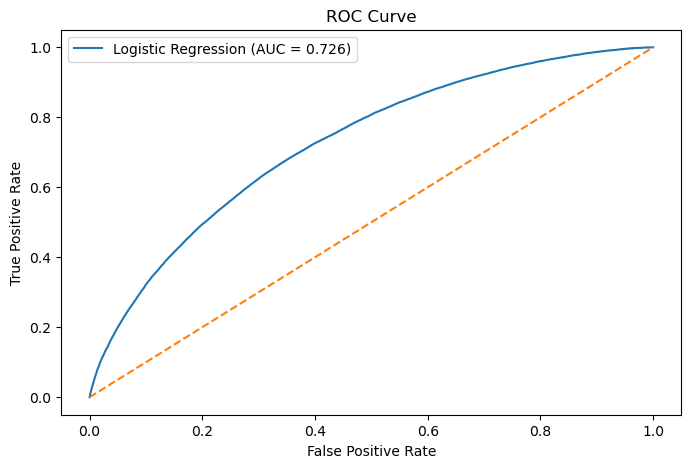

In [25]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Plot precision-recall curve

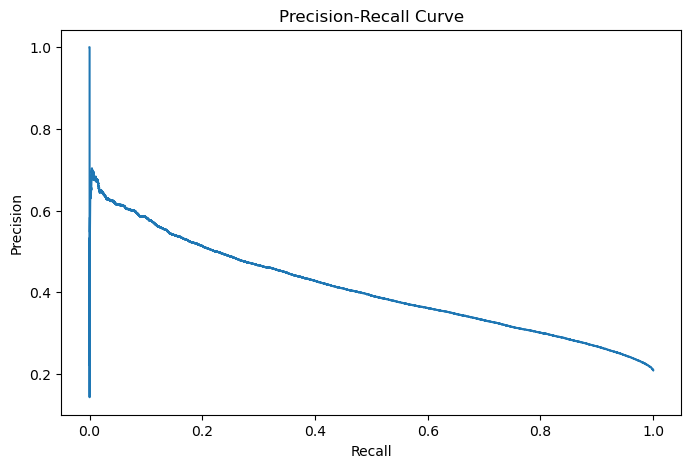

In [26]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## Baseline Model Interpretation

- What is the ROC-AUC?
- Is recall too low to be useful for a lending use case?
- Is the model mostly predicting non-default?
- What does this tell me about the limitations of a default 0.5 threshold?
- Why is this still a useful baseline?